In [ ]:
from __future__ import annotations

import json
import re
import warnings
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Dict, List, Mapping, Optional, Sequence, Tuple, Union

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from collections import Counter


PathLike = Union[str, Path]
TargetDict = Dict[str, torch.Tensor]
MetadataList = List[Dict[str, Any]]


@dataclass(frozen=True)
class ParsedImageName:
    """이미지 파일명에서 파싱한 정보를 저장합니다.

    Attributes:
        combination_key:
            annotation 폴더 이름의 기준이 되는 문자열입니다.
            예: ``K-001900-016548-019607-029451``
        pill_ids:
            이미지에 포함된 알약 ID 목록입니다.
            예: ("001900", "016548", "019607", "029451")
        camera_angle:
            파일명에서 읽은 촬영 각도입니다. 파싱할 수 없으면 None입니다.
        suffix_tokens:
            첫 번째 언더스코어 뒤에 있는 나머지 토큰입니다.
    """

    combination_key: str
    pill_ids: Tuple[str, ...]
    camera_angle: Optional[int]
    suffix_tokens: Tuple[str, ...]


@dataclass
class CachedObject:
    """JSON에서 읽어 메모리에 저장하는 객체 단위 annotation입니다."""

    bbox_xyxy: Tuple[float, float, float, float]
    category_id: int
    area: float
    iscrowd: int
    annotation_id: Optional[int]
    ignore: int
    metadata: Dict[str, Any]


@dataclass
class CachedSample:
    """이미지 한 장에 해당하는 캐시 데이터입니다."""

    image_path: Path
    image_id: int
    parsed_name: ParsedImageName
    objects: List[CachedObject]
    width: Optional[int]
    height: Optional[int]


class PillDetectionDataset(Dataset):
    """알약 multi-class object detection용 PyTorch Dataset입니다.

    Args:
        root:
            데이터셋 루트 경로입니다.
        image_dir_name:
            root 내부 이미지 폴더 이름입니다.
        annotation_dir_name:
            root 내부 annotation 폴더 이름입니다.
        transforms:
            이미지와 bounding box를 함께 변환하는 함수입니다.

            Albumentations 스타일의 경우 다음과 같이 호출 가능한 객체여야 합니다.

            ``transforms(image=np_image, bboxes=boxes, labels=labels)``

            반환값은 최소한 ``image``와 ``bboxes``를 포함해야 합니다.
            ``labels``를 반환하면 변환 이후 label도 갱신합니다.

            일반 callable 스타일의 경우 ``transforms(image, target)`` 형태도
            지원합니다. 반환값은 ``(image, target)``이어야 합니다.
        image_extensions:
            데이터셋으로 수집할 이미지 확장자 목록입니다.
        label_offset:
            원본 category_id를 연속 label로 매핑할 때 시작 인덱스입니다.
            torchvision detection은 보통 1, YOLO는 보통 0을 사용합니다.
        strict:
            True이면 annotation 누락, 객체 수 불일치, 잘못된 JSON 등에 대해
            예외를 발생시킵니다. False이면 경고 후 가능한 샘플만 사용합니다.
        validate_image_size:
            True이면 JSON의 width/height와 실제 이미지 크기가 일치하는지
            __getitem__에서 확인합니다.
        include_raw_metadata:
            True이면 각 객체 metadata에 JSON의 images/categories/annotation
            원본 레코드를 추가로 보관합니다. 메모리 사용량이 증가할 수 있습니다.

    Returns from __getitem__:
        image:
            PIL.Image.Image, numpy.ndarray 또는 torch.Tensor입니다.
            transform 설정에 따라 타입이 달라집니다.
        target:
            torchvision detection 스타일 딕셔너리입니다.
            ``boxes``, ``labels``, ``image_id``, ``area``, ``iscrowd``를 포함합니다.
        metadata:
            이미지 및 객체 단위 부가정보를 담은 딕셔너리입니다.
            객체 정보는 ``metadata["objects"]``에 들어 있습니다.
    """

    _FILENAME_PATTERN = re.compile(
        r"^(?P<combo>K(?:-\d{6}){3,4})_(?P<suffix>.+)$"
    )

    def __init__(
        self,
        root: PathLike,
        transforms: Optional[Callable[..., Any]] = None,
        image_dir_name: str = "train_images",
        annotation_dir_name: str = "train_annotations",
        image_extensions: Sequence[str] = (".png", ".jpg", ".jpeg", ".bmp", ".webp"),
        label_offset: int = 1,
        strict: bool = True,
        validate_image_size: bool = False,
        include_raw_metadata: bool = False,
    ) -> None:
        super().__init__()

        if label_offset < 0:
            raise ValueError("label_offset은 0 이상의 정수여야 합니다.")

        self.root = Path(root)
        self.image_dir = self.root / image_dir_name
        self.annotation_dir = self.root / annotation_dir_name
        self.transforms = transforms
        self.image_extensions = tuple(ext.lower() for ext in image_extensions)
        self.label_offset = label_offset
        self.strict = strict
        self.validate_image_size = validate_image_size
        self.include_raw_metadata = include_raw_metadata

        self._validate_directories()

        # JSON을 정확히 한 번만 읽은 뒤 임시 CachedSample 목록을 생성합니다.
        raw_samples, category_records = self._build_cache_once()

        # COCO category_id는 1900, 16548처럼 비연속적일 수 있으므로
        # 학습에 적합한 연속 label로 매핑합니다.
        category_ids = sorted(category_records.keys())
        self.cat2label: Dict[int, int] = {
            category_id: index + self.label_offset
            for index, category_id in enumerate(category_ids)
        }
        self.label2cat: Dict[int, int] = {
            label: category_id for category_id, label in self.cat2label.items()
        }

        # category 이름 및 원본 category 레코드도 접근할 수 있게 보관합니다.
        self.category_id_to_name: Dict[int, str] = {
            category_id: str(record.get("name", category_id))
            for category_id, record in category_records.items()
        }
        self.category_records = category_records

        # 클래스 매핑이 생성된 뒤 최종 samples를 구성합니다.
        self.samples: List[Dict[str, Any]] = [
            self._finalize_sample(sample) for sample in raw_samples
        ]

    def _validate_directories(self) -> None:
        """필수 폴더 존재 여부를 확인합니다."""

        if not self.root.exists():
            raise FileNotFoundError(f"데이터셋 root가 존재하지 않습니다: {self.root}")
        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"이미지 폴더가 존재하지 않습니다: {self.image_dir}")
        if not self.annotation_dir.is_dir():
            raise FileNotFoundError(
                f"annotation 폴더가 존재하지 않습니다: {self.annotation_dir}"
            )

    @classmethod
    def parse_image_filename(cls, image_path: PathLike) -> ParsedImageName:
        """이미지 파일명을 파싱합니다.

        지원 예시:
            K-001900-016548-019607-029451_0_2_0_2_70_000_200.png
            K-001900-016548-019607_0_2_0_2_75_000_200.png

        촬영 각도는 suffix 토큰 중 5번째 값(index 4)을 우선 사용합니다.
        현재 설명된 파일 규칙에서는 70, 75, 90이 이 위치에 있습니다.
        """

        path = Path(image_path)
        match = cls._FILENAME_PATTERN.match(path.stem)
        if match is None:
            raise ValueError(
                "지원하지 않는 이미지 파일명 형식입니다: "
                f"{path.name}"
            )

        combination_key = match.group("combo")
        suffix_tokens = tuple(match.group("suffix").split("_"))
        pill_ids = tuple(combination_key.split("-")[1:])

        camera_angle: Optional[int] = None
        if len(suffix_tokens) > 4:
            try:
                camera_angle = int(suffix_tokens[4])
            except ValueError:
                camera_angle = None

        return ParsedImageName(
            combination_key=combination_key,
            pill_ids=pill_ids,
            camera_angle=camera_angle,
            suffix_tokens=suffix_tokens,
        )

    def _iter_image_files(self) -> List[Path]:
        """지원 확장자를 가진 이미지 파일을 정렬해 반환합니다."""

        files = [
            path
            for path in self.image_dir.iterdir()
            if path.is_file() and path.suffix.lower() in self.image_extensions
        ]
        return sorted(files, key=lambda path: path.name)

    def _handle_problem(self, message: str, exception_type: type[Exception] = RuntimeError) -> None:
        """strict 설정에 따라 예외를 발생시키거나 경고만 출력합니다."""

        if self.strict:
            raise exception_type(message)
        warnings.warn(message, RuntimeWarning, stacklevel=2)

    def _find_json_files(self, image_path: Path, parsed: ParsedImageName) -> List[Path]:
        """이미지 한 장에 대응하는 객체별 JSON 파일들을 찾습니다.

        annotation 폴더 예시:
            train_annotations/K-001900-...-029451_json/

        하위의 각 K-{ID} 폴더에서 이미지 stem과 동일한 JSON 파일을 찾습니다.
        """

        annotation_group_dir = self.annotation_dir / f"{parsed.combination_key}_json"
        if not annotation_group_dir.is_dir():
            self._handle_problem(
                f"annotation 그룹 폴더가 없습니다: {annotation_group_dir}",
                FileNotFoundError,
            )
            return []

        expected_name = f"{image_path.stem}.json"
        json_files = sorted(annotation_group_dir.rglob(expected_name))

        expected_count = len(parsed.pill_ids)
        if len(json_files) != expected_count:
            self._handle_problem(
                f"이미지 {image_path.name}의 알약 ID 수는 {expected_count}개지만 "
                f"대응 JSON은 {len(json_files)}개입니다."
            )

        return json_files

    def _build_cache_once(
        self,
    ) -> Tuple[List[CachedSample], Dict[int, Dict[str, Any]]]:
        """모든 JSON을 한 번만 읽어 전체 annotation 캐시를 생성합니다."""

        raw_samples: List[CachedSample] = []
        category_records: Dict[int, Dict[str, Any]] = {}

        image_files = self._iter_image_files()
        if not image_files:
            self._handle_problem(f"이미지 폴더가 비어 있습니다: {self.image_dir}")

        for image_id, image_path in enumerate(image_files):
            try:
                parsed = self.parse_image_filename(image_path)
            except ValueError as exc:
                self._handle_problem(str(exc), ValueError)
                continue

            json_files = self._find_json_files(image_path, parsed)
            if not json_files:
                # strict=False일 때 annotation 없는 샘플은 제외합니다.
                continue

            objects: List[CachedObject] = []
            sample_width: Optional[int] = None
            sample_height: Optional[int] = None

            for json_path in json_files:
                try:
                    with json_path.open("r", encoding="utf-8") as file:
                        payload = json.load(file)
                    cached_object, image_record, category_record = self._parse_json_payload(
                        payload=payload,
                        json_path=json_path,
                    )
                except (OSError, json.JSONDecodeError, KeyError, IndexError, TypeError, ValueError) as exc:
                    self._handle_problem(
                        f"JSON 파싱 실패: {json_path}\n원인: {exc}",
                        type(exc) if isinstance(exc, Exception) else RuntimeError,
                    )
                    continue

                objects.append(cached_object)

                width = image_record.get("width")
                height = image_record.get("height")
                if width is not None:
                    sample_width = int(width)
                if height is not None:
                    sample_height = int(height)

                category_id = cached_object.category_id
                if category_record:
                    category_records.setdefault(category_id, category_record)
                else:
                    category_records.setdefault(
                        category_id,
                        {
                            "id": category_id,
                            "name": cached_object.metadata.get("drug_name", str(category_id)),
                            "supercategory": "pill",
                        },
                    )

            if not objects:
                self._handle_problem(
                    f"유효한 annotation 객체가 없는 이미지입니다: {image_path.name}"
                )
                continue

            # 파일명 ID와 JSON의 drug ID를 비교해 데이터 오류를 조기에 찾습니다.
            json_pill_ids = {
                self._normalize_pill_id(obj.metadata.get("drug_code")) for obj in objects
            }
            filename_pill_ids = set(parsed.pill_ids)
            if None not in json_pill_ids and json_pill_ids != filename_pill_ids:
                self._handle_problem(
                    f"파일명 알약 ID와 JSON drug_N이 일치하지 않습니다. "
                    f"image={image_path.name}, filename={sorted(filename_pill_ids)}, "
                    f"json={sorted(json_pill_ids)}"
                )

            raw_samples.append(
                CachedSample(
                    image_path=image_path,
                    image_id=image_id,
                    parsed_name=parsed,
                    objects=objects,
                    width=sample_width,
                    height=sample_height,
                )
            )

        if not raw_samples:
            raise RuntimeError("사용 가능한 image/annotation 샘플을 찾지 못했습니다.")

        return raw_samples, category_records

    def _parse_json_payload(
        self,
        payload: Mapping[str, Any],
        json_path: Path,
    ) -> Tuple[CachedObject, Dict[str, Any], Dict[str, Any]]:
        """객체 하나에 해당하는 JSON payload를 CachedObject로 변환합니다."""

        images = payload.get("images", [])
        annotations = payload.get("annotations", [])
        categories = payload.get("categories", [])

        if not images:
            raise ValueError("images 항목이 비어 있습니다.")
        if not annotations:
            raise ValueError("annotations 항목이 비어 있습니다.")

        image_record = dict(images[0])
        annotation_record = dict(annotations[0])
        category_record = dict(categories[0]) if categories else {}

        bbox = annotation_record.get("bbox")
        if not isinstance(bbox, Sequence) or len(bbox) != 4:
            raise ValueError(f"bbox 형식이 올바르지 않습니다: {bbox}")

        x, y, width, height = map(float, bbox)
        if width <= 0 or height <= 0:
            raise ValueError(f"bbox의 width/height는 양수여야 합니다: {bbox}")

        x2 = x + width
        y2 = y + height
        category_id = int(annotation_record["category_id"])

        # 추가 데이터 일부는 실제 약 정보가 images에 있음에도 COCO category가
        # {id: 1, name: 'Drug'}라는 placeholder로 저장되어 있습니다.
        # 이 경우 drug_N과 dl_name을 사용해 실제 category 정보를 복원합니다.
        is_placeholder_category = (
            category_id == 1
            and self._optional_int(category_record.get("id")) == 1
            and str(category_record.get("name", "")).strip().lower() == "drug"
        )
        if is_placeholder_category:
            normalized_pill_id = self._normalize_pill_id(image_record.get("drug_N"))
            if normalized_pill_id is None or not normalized_pill_id.isdigit():
                raise ValueError(
                    "placeholder category를 복원할 drug_N이 올바르지 않습니다: "
                    f"{image_record.get('drug_N')}"
                )

            category_id = int(normalized_pill_id)
            drug_name = image_record.get("dl_name")
            if drug_name is None or not str(drug_name).strip():
                drug_name = f"K-{normalized_pill_id}"

            # 아래 로직 전체가 보정된 값을 사용하도록 복사본을 갱신합니다.
            annotation_record["category_id"] = category_id
            category_record = {
                **category_record,
                "id": category_id,
                "name": str(drug_name),
                "supercategory": category_record.get("supercategory", "pill"),
            }

        # area 값이 없거나 잘못된 경우 bbox 면적으로 보정합니다.
        area_value = annotation_record.get("area", width * height)
        area = float(area_value)
        if area <= 0:
            area = width * height

        metadata = self._extract_metadata(
            image_record=image_record,
            annotation_record=annotation_record,
            category_record=category_record,
            json_path=json_path,
        )

        return (
            CachedObject(
                bbox_xyxy=(x, y, x2, y2),
                category_id=category_id,
                area=area,
                iscrowd=int(annotation_record.get("iscrowd", 0)),
                annotation_id=self._optional_int(annotation_record.get("id")),
                ignore=int(annotation_record.get("ignore", 0)),
                metadata=metadata,
            ),
            image_record,
            category_record,
        )

    def _extract_metadata(
        self,
        image_record: Mapping[str, Any],
        annotation_record: Mapping[str, Any],
        category_record: Mapping[str, Any],
        json_path: Path,
    ) -> Dict[str, Any]:
        """JSON의 부가 정보를 객체별 metadata 딕셔너리로 정리합니다."""

        metadata: Dict[str, Any] = {
            # 파일/식별 정보
            "annotation_json_path": str(json_path),
            "annotation_id": annotation_record.get("id"),
            "source_image_id": image_record.get("id"),
            "source_image_file_name": image_record.get("file_name"),
            "drug_code": image_record.get("drug_N"),
            "mapping_code": image_record.get("dl_mapping_code"),
            "drug_index": image_record.get("dl_idx"),
            "item_seq": image_record.get("item_seq"),
            # 이름/성분/회사
            "drug_name": image_record.get("dl_name"),
            "drug_name_en": image_record.get("dl_name_en"),
            "material": image_record.get("dl_material"),
            "material_en": image_record.get("dl_material_en"),
            "company": image_record.get("dl_company"),
            "company_en": image_record.get("dl_company_en"),
            "manufacturer": image_record.get("di_company_mf"),
            "manufacturer_en": image_record.get("di_company_mf_en"),
            # 외형
            "drug_status": image_record.get("drug_S"),
            "custom_shape": image_record.get("dl_custom_shape"),
            "shape": image_record.get("drug_shape"),
            "color1": image_record.get("color_class1"),
            "color2": image_record.get("color_class2"),
            "chart": image_record.get("chart"),
            "form_code_name": image_record.get("form_code_name"),
            "length_long": image_record.get("leng_long"),
            "length_short": image_record.get("leng_short"),
            "thickness": image_record.get("thick"),
            # 각인/분할선
            "front_print": image_record.get("print_front"),
            "back_print": image_record.get("print_back"),
            "front_line": image_record.get("line_front"),
            "back_line": image_record.get("line_back"),
            "mark_code_front": image_record.get("mark_code_front"),
            "mark_code_back": image_record.get("mark_code_back"),
            "mark_code_front_analysis": image_record.get("mark_code_front_anal"),
            "mark_code_back_analysis": image_record.get("mark_code_back_anal"),
            # 촬영 환경
            "direction": image_record.get("drug_dir"),
            "background": image_record.get("back_color"),
            "light": image_record.get("light_color"),
            "camera_latitude": image_record.get("camera_la"),
            "camera_longitude": image_record.get("camera_lo"),
            "source_size": image_record.get("size"),
            # 허가/분류 정보
            "permit_date": image_record.get("di_item_permit_date"),
            "class_number": image_record.get("di_class_no"),
            "etc_otc_code": image_record.get("di_etc_otc_code"),
            "edi_code": image_record.get("di_edi_code"),
            "registration_timestamp": image_record.get("img_regist_ts"),
            "change_date": image_record.get("change_date"),
            # 외부 이미지 참조
            "image_url": image_record.get("img_key"),
            # COCO category 정보
            "category_name": category_record.get("name"),
            "supercategory": category_record.get("supercategory"),
        }

        if self.include_raw_metadata:
            metadata["raw_image_record"] = dict(image_record)
            metadata["raw_annotation_record"] = dict(annotation_record)
            metadata["raw_category_record"] = dict(category_record)

        return metadata

    def _finalize_sample(self, sample: CachedSample) -> Dict[str, Any]:
        """CachedSample을 __getitem__에서 바로 사용할 최종 구조로 변환합니다."""

        boxes: List[Tuple[float, float, float, float]] = []
        labels: List[int] = []
        areas: List[float] = []
        iscrowd: List[int] = []
        annotation_ids: List[int] = []
        ignore_flags: List[int] = []
        object_metadata: MetadataList = []

        for obj in sample.objects:
            label = self.cat2label[obj.category_id]

            boxes.append(obj.bbox_xyxy)
            labels.append(label)
            areas.append(obj.area)
            iscrowd.append(obj.iscrowd)
            annotation_ids.append(-1 if obj.annotation_id is None else obj.annotation_id)
            ignore_flags.append(obj.ignore)

            metadata = deepcopy(obj.metadata)
            metadata["category_id"] = obj.category_id
            metadata["class_index"] = label
            metadata["class_name"] = self.category_id_to_name.get(
                obj.category_id,
                str(obj.category_id),
            )
            object_metadata.append(metadata)

        target: TargetDict = {
            "boxes": self._boxes_tensor(boxes),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([sample.image_id], dtype=torch.int64),
            "area": torch.tensor(areas, dtype=torch.float32),
            "iscrowd": torch.tensor(iscrowd, dtype=torch.int64),
            # 아래 항목은 필수는 아니지만 COCO 원본과의 추적 및 분석에 유용합니다.
            "annotation_id": torch.tensor(annotation_ids, dtype=torch.int64),
            "ignore": torch.tensor(ignore_flags, dtype=torch.int64),
        }

        metadata: Dict[str, Any] = {
            "image_path": str(sample.image_path),
            "file_name": sample.image_path.name,
            "image_stem": sample.image_path.stem,
            "image_id": sample.image_id,
            "width": sample.width,
            "height": sample.height,
            "combination_key": sample.parsed_name.combination_key,
            "pill_ids": list(sample.parsed_name.pill_ids),
            "pill_codes": [f"K-{pill_id}" for pill_id in sample.parsed_name.pill_ids],
            "num_pills": len(sample.objects),
            "camera_angle_from_filename": sample.parsed_name.camera_angle,
            "filename_suffix_tokens": list(sample.parsed_name.suffix_tokens),
            "objects": object_metadata,
        }

        return {
            "image_path": sample.image_path,
            "target": target,
            "metadata": metadata,
        }

    @staticmethod
    def _boxes_tensor(boxes: Sequence[Sequence[float]]) -> torch.Tensor:
        """빈 객체도 항상 (N, 4) 형태가 되도록 boxes tensor를 만듭니다."""

        if not boxes:
            return torch.zeros((0, 4), dtype=torch.float32)
        return torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)

    @staticmethod
    def _optional_int(value: Any) -> Optional[int]:
        """None을 허용하면서 값을 int로 변환합니다."""

        if value is None or value == "":
            return None
        return int(value)

    @staticmethod
    def _normalize_pill_id(value: Any) -> Optional[str]:
        """K-001900 또는 001900을 파일명 형식의 6자리 ID로 정규화합니다."""

        if value is None:
            return None
        text = str(value).strip()
        if text.startswith("K-"):
            text = text[2:]
        return text.zfill(6) if text.isdigit() else text

    def __len__(self) -> int:
        """사용 가능한 이미지 샘플 수를 반환합니다."""

        return len(self.samples)

    def __getitem__(self, index: int) -> Tuple[Any, TargetDict, Dict[str, Any]]:
        """이미지, COCO 스타일 target, metadata를 반환합니다."""

        sample = self.samples[index]
        image_path: Path = sample["image_path"]

        # 초기화 시 JSON은 이미 모두 캐시했으므로, 여기서는 이미지만 디스크에서 읽습니다.
        with Image.open(image_path) as opened_image:
            image = opened_image.convert("RGB")

        target: TargetDict = {
            key: value.clone() for key, value in sample["target"].items()
        }
        metadata: Dict[str, Any] = deepcopy(sample["metadata"])

        if self.validate_image_size:
            actual_width, actual_height = image.size
            expected_width = metadata.get("width")
            expected_height = metadata.get("height")
            if (
                expected_width is not None
                and expected_height is not None
                and (actual_width, actual_height) != (expected_width, expected_height)
            ):
                raise ValueError(
                    f"이미지 크기 불일치: {image_path.name}, "
                    f"actual={(actual_width, actual_height)}, "
                    f"json={(expected_width, expected_height)}"
                )

        if self.transforms is not None:
            image, target, metadata = self._apply_transforms(image, target, metadata)

        return image, target, metadata

    def _apply_transforms(
        self,
        image: Image.Image,
        target: TargetDict,
        metadata: Dict[str, Any],
    ) -> Tuple[Any, TargetDict, Dict[str, Any]]:
        """Albumentations 또는 일반 detection transform을 적용합니다."""

        boxes_before = target["boxes"]
        labels_before = target["labels"]

        # 먼저 Albumentations 스타일을 시도합니다.
        try:
            transformed = self.transforms(
                image=np.asarray(image),
                bboxes=boxes_before.cpu().numpy().tolist(),
                labels=labels_before.cpu().numpy().tolist(),
            )
        except TypeError:
            # Albumentations 스타일이 아니면 torchvision 사용자 정의 transform처럼
            # (image, target) -> (image, target) 호출을 시도합니다.
            transformed = self.transforms(image, target)
            if not isinstance(transformed, tuple) or len(transformed) != 2:
                raise TypeError(
                    "일반 transform은 (image, target) 형태의 2개 값을 반환해야 합니다."
                )
            transformed_image, transformed_target = transformed
            return transformed_image, transformed_target, metadata

        if not isinstance(transformed, Mapping):
            raise TypeError("Albumentations 스타일 transform은 dict를 반환해야 합니다.")
        if "image" not in transformed or "bboxes" not in transformed:
            raise KeyError("transform 반환값에는 image와 bboxes가 필요합니다.")

        transformed_image = transformed["image"]
        transformed_boxes = self._boxes_tensor(transformed["bboxes"])
        transformed_labels = torch.as_tensor(
            transformed.get("labels", labels_before.tolist()),
            dtype=torch.int64,
        )

        # Albumentations에서 min_visibility 등으로 bbox가 제거될 수 있습니다.
        # labels뿐 아니라 area, iscrowd, annotation_id, ignore, metadata도 같은 인덱스로
        # 맞춰야 합니다. 가장 안전한 방법은 object_indices를 추가 label_field로
        # 전달하는 것이지만, 기존 transform과의 호환을 위해 label 기반 매칭을 제공합니다.
        # 동일 클래스 객체가 여러 개 존재할 수 있으므로 bbox 개수가 달라진 경우에는
        # metadata 정렬을 완벽히 보장할 수 없습니다. 그런 경우 아래 경고를 출력합니다.
        if len(transformed_boxes) != len(boxes_before):
            warnings.warn(
                "transform 과정에서 bbox 개수가 변경되었습니다. "
                "target의 area/iscrowd 및 metadata 객체 목록은 bbox 개수에 맞춰 앞에서부터 "
                "잘립니다. 정확한 객체 추적이 필요하면 Albumentations label_fields에 "
                "object_indices를 함께 사용하도록 transform wrapper를 구성하십시오.",
                RuntimeWarning,
                stacklevel=2,
            )

        kept_count = len(transformed_boxes)
        target["boxes"] = transformed_boxes
        target["labels"] = transformed_labels.reshape(-1)

        # resize/rotation 이후에는 기존 area가 유효하지 않으므로 새 bbox 면적으로 계산합니다.
        if kept_count > 0:
            widths = (transformed_boxes[:, 2] - transformed_boxes[:, 0]).clamp(min=0)
            heights = (transformed_boxes[:, 3] - transformed_boxes[:, 1]).clamp(min=0)
            target["area"] = widths * heights
        else:
            target["area"] = torch.zeros((0,), dtype=torch.float32)

        for key in ("iscrowd", "annotation_id", "ignore"):
            target[key] = target[key][:kept_count]

        metadata["objects"] = metadata["objects"][:kept_count]
        metadata["num_pills_after_transform"] = kept_count

        return transformed_image, target, metadata

    @property
    def num_classes(self) -> int:
        """실제 알약 클래스 수를 반환합니다. background는 포함하지 않습니다."""

        return len(self.cat2label)

    def get_class_name(self, label: int) -> str:
        """학습용 label에 대응하는 알약 이름을 반환합니다."""

        if label not in self.label2cat:
            raise KeyError(f"존재하지 않는 label입니다: {label}")
        category_id = self.label2cat[label]
        return self.category_id_to_name[category_id]

    def get_category_id(self, label: int) -> int:
        """학습용 label을 원본 COCO category_id로 변환합니다."""

        if label not in self.label2cat:
            raise KeyError(f"존재하지 않는 label입니다: {label}")
        return self.label2cat[label]

    def get_label(self, category_id: int) -> int:
        """원본 COCO category_id를 학습용 연속 label로 변환합니다."""

        if category_id not in self.cat2label:
            raise KeyError(f"존재하지 않는 category_id입니다: {category_id}")
        return self.cat2label[category_id]

    def get_sample_summary(self, index: int) -> Dict[str, Any]:
        """이미지를 읽지 않고 샘플의 요약 정보만 반환합니다."""

        sample = self.samples[index]
        target = sample["target"]
        metadata = sample["metadata"]
        return {
            "index": index,
            "file_name": metadata["file_name"],
            "pill_ids": list(metadata["pill_ids"]),
            "num_pills": int(target["boxes"].shape[0]),
            "labels": target["labels"].tolist(),
            "category_ids": [
                self.label2cat[label] for label in target["labels"].tolist()
            ],
            "camera_angle": metadata["camera_angle_from_filename"],
        }

    def print_class_statistics(self) -> None:
        """모든 클래스의 class ID, pill ID, 약 이름, 객체 개수를 출력합니다."""

        instance_counts: Counter[int] = Counter()

        for sample in self.samples:
            instance_counts.update(sample["target"]["labels"].tolist())

        header = (
            f"{'class id':>10}  "
            f"{'pill id':>12}  "
            f"{'drug name':<40}  "
            f"{'data count':>12}"
        )

        print(header)
        print("-" * len(header))

        for class_id in sorted(self.label2cat):
            category_id = self.label2cat[class_id]
            pill_id = f"K-{category_id:06d}"
            drug_name = self.category_id_to_name.get(
                category_id,
                "Unknown",
            )
            data_count = instance_counts[class_id]

            print(
                f"{class_id:>10}  "
                f"{pill_id:>12}  "
                f"{drug_name:<40}  "
                f"{data_count:>12}"
            )

        print("-" * len(header))
        print(f"클래스 수: {self.num_classes}")
        print(f"전체 객체 수: {sum(instance_counts.values())}")


def detection_collate_fn(
    batch: Sequence[Tuple[Any, TargetDict, Dict[str, Any]]]
) -> Tuple[List[Any], List[TargetDict], List[Dict[str, Any]]]:
    """객체 탐지 DataLoader용 collate 함수입니다.

    이미지마다 객체 수가 3개 또는 4개로 다르므로 기본 collate 함수처럼
    target을 하나의 tensor로 stack할 수 없습니다. 따라서 이미지, target,
    metadata를 각각 list 형태로 묶어 반환합니다.
    """

    images, targets, metadata = zip(*batch)
    return list(images), list(targets), list(metadata)

In [8]:
#dataset_root = "./sprint_ai_project1_data"
dataset_root = "../data/dataset/cleaning_data" #현재 git 폴더 구조에 맞도록 변경

dataset = PillDetectionDataset(
    root=dataset_root,
    transforms=None,
    label_offset=1,  # torchvision detection 기준. YOLO용이면 0 권장.
    strict=False,  # 일부 annotation 누락/불일치가 있어도 경고 후 진행
    validate_image_size=True,
)

print(f"Number of images: {len(dataset)}")
print(f"Number of pill classes: {dataset.num_classes}")
print("First sample summary:")
print(dataset.get_sample_summary(0))

image, target, metadata = dataset[0]
print(f"Image size: {image.size}")
print(f"Boxes shape: {target['boxes'].shape}")
print(f"Boxes: {target['boxes']}")
print(f"Labels: {target['labels'].tolist()}")
print(f"Pill IDs: {metadata['pill_ids']}")
print(f"First object metadata: {metadata['objects'][0]}")
print(f"Second object metadata: {metadata['objects'][1]}")
print(f"Third object metadata: {metadata['objects'][2]}")
print(f"Fourth object metadata: {metadata['objects'][3]}")

dataset.print_class_statistics()



Number of images: 219
Number of pill classes: 56
First sample summary:
{'index': 0, 'file_name': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'pill_ids': ['001900', '016548', '019607', '029451'], 'num_pills': 4, 'labels': [1, 16, 23, 43], 'category_ids': [1900, 16548, 19607, 29451], 'camera_angle': 70}
Image size: (976, 1280)
Boxes shape: torch.Size([4, 4])
Boxes: tensor([[ 644.,  845.,  833., 1035.],
        [ 144.,  799.,  383., 1038.],
        [ 657.,  287.,  812.,  437.],
        [ 108.,  218.,  500.,  482.]])
Labels: [1, 16, 23, 43]
Pill IDs: ['001900', '016548', '019607', '029451']
First object metadata: {'annotation_json_path': '..\\data\\dataset\\cleaning_data\\train_annotations\\K-001900-016548-019607-029451_json\\K-001900\\K-001900-016548-019607-029451_0_2_0_2_70_000_200.json', 'annotation_id': 133, 'source_image_id': 34, 'source_image_file_name': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'drug_code': 'K-001900', 'mapping_code': 'K-001900', 'drug_inde

## 데이터셋을 train/val/test set으로 나누기 위한 코드

데이터로더까지 설정함: train_loader, valid_loader, test_loader

In [9]:
from collections import defaultdict

import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset


# ============================================================
# 1. 기본 설정
# ============================================================
#dataset_root = "./sprint_ai_project1_data"
dataset_root = "../data/dataset/cleaning_data"  #현재 git 폴더 구조에 맞도록 변경
random_seed = 42
batch_size = 4

# Albumentations 등을 사용하는 경우 여기에 지정합니다.
# 예:
# train_transforms = A.Compose(
#     [...],
#     bbox_params=A.BboxParams(
#         format="pascal_voc",
#         label_fields=["labels"],
#     ),
# )
#
# valid/test에는 resize 및 tensor 변환 등 평가에 필요한 변환만 지정합니다.
train_transforms = None
eval_transforms = None


# ============================================================
# 2. 분할 기준으로 사용할 데이터셋 생성
# ============================================================
# transforms=None으로 생성하여 데이터 분할 정보만 확인합니다.
split_base_dataset = PillDetectionDataset(
    root=dataset_root,
    transforms=None,
    label_offset=1,
    strict=False,
    validate_image_size=True,
)

print(f"전체 이미지 수: {len(split_base_dataset)}")
print(f"알약 클래스 수: {split_base_dataset.num_classes}")


# ============================================================
# 3. combination_key 단위로 이미지 인덱스 그룹화
# ============================================================
group_to_indices = defaultdict(list)

for index, sample in enumerate(split_base_dataset.samples):
    combination_key = sample["metadata"]["combination_key"]
    group_to_indices[combination_key].append(index)

group_keys = sorted(group_to_indices.keys())

print(f"전체 combination_key 수: {len(group_keys)}")


# ============================================================
# 4. combination_key를 Train / Validation / Test = 8:1:1로 분할
# ============================================================
# 먼저 전체 그룹의 80%를 train, 20%를 validation+test로 분리합니다.
train_groups, temp_groups = train_test_split(
    group_keys,
    test_size=0.2,
    random_state=random_seed,
    shuffle=True,
)

# 남은 20%를 절반으로 나눠 validation 10%, test 10%로 만듭니다.
valid_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.5,
    random_state=random_seed,
    shuffle=True,
)

train_groups = set(train_groups)
valid_groups = set(valid_groups)
test_groups = set(test_groups)


def groups_to_indices(groups, group_mapping):
    """combination_key 집합을 원본 데이터셋 인덱스 목록으로 변환합니다."""
    return sorted(
        index
        for group in groups
        for index in group_mapping[group]
    )


train_indices = groups_to_indices(train_groups, group_to_indices)
valid_indices = groups_to_indices(valid_groups, group_to_indices)
test_indices = groups_to_indices(test_groups, group_to_indices)


# ============================================================
# 5. combination_key 누수 여부 검증
# ============================================================
assert train_groups.isdisjoint(valid_groups), (
    "Train과 Validation에 중복 combination_key가 있습니다."
)
assert train_groups.isdisjoint(test_groups), (
    "Train과 Test에 중복 combination_key가 있습니다."
)
assert valid_groups.isdisjoint(test_groups), (
    "Validation과 Test에 중복 combination_key가 있습니다."
)

# 모든 이미지가 정확히 한 번씩 분배되었는지 확인
all_split_indices = train_indices + valid_indices + test_indices

assert len(all_split_indices) == len(split_base_dataset), (
    "분할된 이미지 수와 전체 이미지 수가 일치하지 않습니다."
)
assert len(set(all_split_indices)) == len(split_base_dataset), (
    "두 개 이상의 데이터셋에 중복된 이미지 인덱스가 있습니다."
)


# ============================================================
# 6. Train용 / 평가용 데이터셋을 별도로 생성
# ============================================================
train_base_dataset = PillDetectionDataset(
    root=dataset_root,
    transforms=train_transforms, #none
    label_offset=1,
    strict=False,
    validate_image_size=True,
)

eval_base_dataset = PillDetectionDataset(
    root=dataset_root,
    transforms=eval_transforms, #none
    label_offset=1,
    strict=False,
    validate_image_size=True,
)


# 세 데이터셋의 샘플 순서가 같은지 검증합니다.
assert len(split_base_dataset) == len(train_base_dataset)
assert len(split_base_dataset) == len(eval_base_dataset)

for index in range(len(split_base_dataset)):
    split_file = split_base_dataset.samples[index]["metadata"]["file_name"]
    train_file = train_base_dataset.samples[index]["metadata"]["file_name"]
    eval_file = eval_base_dataset.samples[index]["metadata"]["file_name"]

    assert split_file == train_file == eval_file, (
        f"데이터셋의 샘플 순서가 다릅니다: index={index}, "
        f"split={split_file}, train={train_file}, eval={eval_file}"
    )


# ============================================================
# 7. 동일한 인덱스를 적용해 Subset 생성
# ============================================================
train_dataset = Subset(
    train_base_dataset,
    train_indices,
)

valid_dataset = Subset(
    eval_base_dataset,
    valid_indices,
)

test_dataset = Subset(
    eval_base_dataset,
    test_indices,
)


# ============================================================
# 8. 분할 결과 출력
# ============================================================
total_images = len(split_base_dataset)

print("\n===== 데이터셋 분할 결과 =====")
print(
    f"Train      : {len(train_dataset):4d}장 "
    f"({len(train_dataset) / total_images:.1%}), "
    f"{len(train_groups)}개 조합"
)
print(
    f"Validation : {len(valid_dataset):4d}장 "
    f"({len(valid_dataset) / total_images:.1%}), "
    f"{len(valid_groups)}개 조합"
)
print(
    f"Test       : {len(test_dataset):4d}장 "
    f"({len(test_dataset) / total_images:.1%}), "
    f"{len(test_groups)}개 조합"
)


# ============================================================
# 9. DataLoader 생성
# ============================================================
# Windows + Jupyter 환경에서는 우선 num_workers=0을 권장합니다.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# 10. DataLoader 동작 확인
# ============================================================
train_images, train_targets, train_metadata = next(iter(train_loader))

print("\n===== Train batch 확인 =====")
print(f"배치 이미지 수: {len(train_images)}")
print(f"첫 이미지 크기: {train_images[0].size}")
print(f"첫 target boxes 크기: {train_targets[0]['boxes'].shape}")
print(f"첫 target labels: {train_targets[0]['labels'].tolist()}")
print(f"첫 이미지 combination_key: {train_metadata[0]['combination_key']}")

전체 이미지 수: 219
알약 클래스 수: 56
전체 combination_key 수: 114

===== 데이터셋 분할 결과 =====
Train      :  175장 (79.9%), 91개 조합
Validation :   21장 (9.6%), 11개 조합
Test       :   23장 (10.5%), 12개 조합

===== Train batch 확인 =====
배치 이미지 수: 4
첫 이미지 크기: (976, 1280)
첫 target boxes 크기: torch.Size([3, 4])
첫 target labels: [3, 21, 28]
첫 이미지 combination_key: K-003351-019232-021325


## Train/val/test 셋으로 나눈 데이터를 Ultranalytics에 사용할 수 있도록 
## 폴더로 저장 및 bbox 좌표 변화, dataset.yaml 생성: 
## 분할 결과가 섞이지 않게 기존 데이터(processed/images, processed/labels)는 삭제하고 실행하세요

폴더의 패스(yolo_root)는 파일 가장 위에서 지정하게 되어있습니다. 현재 git 폴더 구조에 맞도록 변경하였습니다.

In [10]:
from pathlib import Path
import shutil

import yaml
from PIL import Image


# ============================================================
# 1. 저장 경로 설정
# ============================================================
#yolo_root = Path("./pill_yolo_dataset")
yolo_root = Path("../data/processed") #현재 git 폴더 구조에 맞도록 변경
split_directories = {
    "train": {
        "images": yolo_root / "images" / "train",
        "labels": yolo_root / "labels" / "train",
    },
    "val": {
        "images": yolo_root / "images" / "val",
        "labels": yolo_root / "labels" / "val",
    },
    "test": {
        "images": yolo_root / "images" / "test",
        "labels": yolo_root / "labels" / "test",
    },
}

for directories in split_directories.values():
    directories["images"].mkdir(parents=True, exist_ok=True)
    directories["labels"].mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. 기존 파일 확인
# ============================================================
# 이전 분할 결과와 새 결과가 섞이는 것을 방지합니다.
existing_files = [
    file_path
    for directories in split_directories.values()
    for directory in directories.values()
    for file_path in directory.iterdir()
    if file_path.is_file()
]

if existing_files:
    raise RuntimeError(
        f"{yolo_root.resolve()}에 기존 이미지 또는 라벨 파일이 있습니다.\n"
        "기존 폴더를 삭제하거나 yolo_root를 다른 경로로 변경한 후 "
        "다시 실행해 주세요."
    )


# ============================================================
# 3. xyxy bbox를 YOLO 형식으로 변환
# ============================================================
def xyxy_to_yolo(box, image_width, image_height):
    """
    픽셀 좌표 [x1, y1, x2, y2]를 정규화된
    [x_center, y_center, width, height]로 변환합니다.
    """
    x1, y1, x2, y2 = map(float, box)

    # bbox를 이미지 경계 안으로 제한
    x1 = max(0.0, min(x1, float(image_width)))
    y1 = max(0.0, min(y1, float(image_height)))
    x2 = max(0.0, min(x2, float(image_width)))
    y2 = max(0.0, min(y2, float(image_height)))

    box_width = x2 - x1
    box_height = y2 - y1

    if box_width <= 0 or box_height <= 0:
        return None

    x_center = (x1 + x2) / 2.0
    y_center = (y1 + y2) / 2.0

    return (
        x_center / image_width,
        y_center / image_height,
        box_width / image_width,
        box_height / image_height,
    )


# ============================================================
# 4. 한 개 split을 YOLO 구조로 저장하는 함수
# ============================================================
def export_split_to_yolo(
    dataset,
    indices,
    destination_image_dir,
    destination_label_dir,
    split_name,
):
    exported_images = 0
    exported_objects = 0
    skipped_boxes = 0

    for count, dataset_index in enumerate(indices, start=1):
        sample = dataset.samples[dataset_index]

        source_image_path = Path(sample["image_path"])
        target = sample["target"]

        destination_image_path = (
            destination_image_dir / source_image_path.name
        )
        destination_label_path = (
            destination_label_dir / f"{source_image_path.stem}.txt"
        )

        # JSON 기록이 아닌 실제 이미지 크기 사용
        with Image.open(source_image_path) as image:
            image_width, image_height = image.size

        boxes = target["boxes"].detach().cpu().numpy()
        labels = target["labels"].detach().cpu().numpy()

        yolo_lines = []

        for box, label in zip(boxes, labels):
            converted_box = xyxy_to_yolo(
                box=box,
                image_width=image_width,
                image_height=image_height,
            )

            if converted_box is None:
                skipped_boxes += 1
                continue

            x_center, y_center, box_width, box_height = converted_box

            # PillDetectionDataset: label_offset=1 → 라벨 1~N
            # Ultralytics YOLO: 클래스 ID 0~N-1
            yolo_class_id = int(label) - dataset.label_offset

            if not 0 <= yolo_class_id < dataset.num_classes:
                raise ValueError(
                    f"YOLO 클래스 ID 범위 오류: "
                    f"split={split_name}, "
                    f"dataset_index={dataset_index}, "
                    f"label={int(label)}, "
                    f"yolo_class_id={yolo_class_id}"
                )

            yolo_lines.append(
                f"{yolo_class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )

            exported_objects += 1

        # 이미지 복사
        shutil.copy2(
            source_image_path,
            destination_image_path,
        )

        # 이미지와 동일한 파일명의 txt 라벨 생성
        destination_label_path.write_text(
            "\n".join(yolo_lines),
            encoding="utf-8",
        )

        exported_images += 1

        if count % 50 == 0 or count == len(indices):
            print(
                f"[{split_name}] "
                f"{count}/{len(indices)} 이미지 처리 완료"
            )

    return {
        "images": exported_images,
        "objects": exported_objects,
        "skipped_boxes": skipped_boxes,
    }


# ============================================================
# 5. Train / Validation / Test 저장
# ============================================================
split_indices = {
    "train": train_indices,
    "val": valid_indices,
    "test": test_indices,
}

export_results = {}

for split_name, indices in split_indices.items():
    export_results[split_name] = export_split_to_yolo(
        dataset=split_base_dataset,
        indices=indices,
        destination_image_dir=split_directories[split_name]["images"],
        destination_label_dir=split_directories[split_name]["labels"],
        split_name=split_name,
    )


# ============================================================
# 6. YOLO 클래스 이름 구성
# ============================================================
class_names = [
    split_base_dataset.get_class_name(
        yolo_class_id + split_base_dataset.label_offset
    )
    for yolo_class_id in range(split_base_dataset.num_classes)
]

assert len(class_names) == split_base_dataset.num_classes


# ============================================================
# 7. data.yaml 생성
# ============================================================
dataset_yaml = {
    "path": str(yolo_root.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": split_base_dataset.num_classes,
    "names": {
        class_id: class_name
        for class_id, class_name in enumerate(class_names)
    },
}

yaml_path = yolo_root / "data.yaml"

with yaml_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(
        dataset_yaml,
        file,
        allow_unicode=True,
        sort_keys=False,
    )


# ============================================================
# 8. 결과 검증
# ============================================================
image_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".webp",
}

for split_name, indices in split_indices.items():
    image_dir = split_directories[split_name]["images"]
    label_dir = split_directories[split_name]["labels"]

    image_files = [
        path
        for path in image_dir.iterdir()
        if path.suffix.lower() in image_extensions
    ]
    label_files = list(label_dir.glob("*.txt"))

    assert len(image_files) == len(indices), (
        f"{split_name} 이미지 개수가 일치하지 않습니다."
    )
    assert len(label_files) == len(indices), (
        f"{split_name} 라벨 개수가 일치하지 않습니다."
    )

    image_stems = {path.stem for path in image_files}
    label_stems = {path.stem for path in label_files}

    assert image_stems == label_stems, (
        f"{split_name} 이미지와 라벨 파일명이 일치하지 않습니다."
    )


# combination_key 누수 여부 재검증
def get_combination_keys(dataset, indices):
    return {
        dataset.samples[index]["metadata"]["combination_key"]
        for index in indices
    }


exported_train_groups = get_combination_keys(
    split_base_dataset,
    train_indices,
)
exported_val_groups = get_combination_keys(
    split_base_dataset,
    valid_indices,
)
exported_test_groups = get_combination_keys(
    split_base_dataset,
    test_indices,
)

assert exported_train_groups.isdisjoint(exported_val_groups)
assert exported_train_groups.isdisjoint(exported_test_groups)
assert exported_val_groups.isdisjoint(exported_test_groups)


# ============================================================
# 9. 최종 결과 출력
# ============================================================
print("\n===== YOLO 데이터셋 생성 완료 =====")
print(f"데이터셋 경로: {yolo_root.resolve()}")
print(f"YAML 경로: {yaml_path.resolve()}")
print(f"클래스 수: {len(class_names)}")

for split_name in ("train", "val", "test"):
    result = export_results[split_name]

    print(
        f"{split_name:>5}: "
        f"이미지 {result['images']}장, "
        f"객체 {result['objects']}개, "
        f"제외된 bbox {result['skipped_boxes']}개"
    )

[train] 50/175 이미지 처리 완료
[train] 100/175 이미지 처리 완료
[train] 150/175 이미지 처리 완료
[train] 175/175 이미지 처리 완료
[val] 21/21 이미지 처리 완료
[test] 23/23 이미지 처리 완료

===== YOLO 데이터셋 생성 완료 =====
데이터셋 경로: C:\Users\soulf\Documents\codeit\pill-object-detection\data\processed
YAML 경로: C:\Users\soulf\Documents\codeit\pill-object-detection\data\processed\data.yaml
클래스 수: 56
train: 이미지 175장, 객체 584개, 제외된 bbox 0개
  val: 이미지 21장, 객체 66개, 제외된 bbox 0개
 test: 이미지 23장, 객체 80개, 제외된 bbox 0개


## 모듈화된 Ultralytics 데이터셋 생성
아래 셀에서 root와 output 경로, 분할 비율만 지정하면 분할·bbox 변환·폴더 저장·data.yaml 생성이 한 번에 수행됩니다.

In [ ]:
import sys
from pathlib import Path

module_dir = Path(r"C:\Users\soulf\Documents\codeit\pill-object-detection\src") #예시
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from PillDetectionDataset import prepare_ultralytics_dataset

result = prepare_ultralytics_dataset(
    root=Path("./sprint_ai_project1_data"),
    output_dir=Path("./data/processed"),
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=42,
)

print(f"data.yaml: {result['yaml_path']}")
print(result["statistics"])

## 이미지 시각화 코드 및 시각화 된 이미지 파일로 내보내는 코드

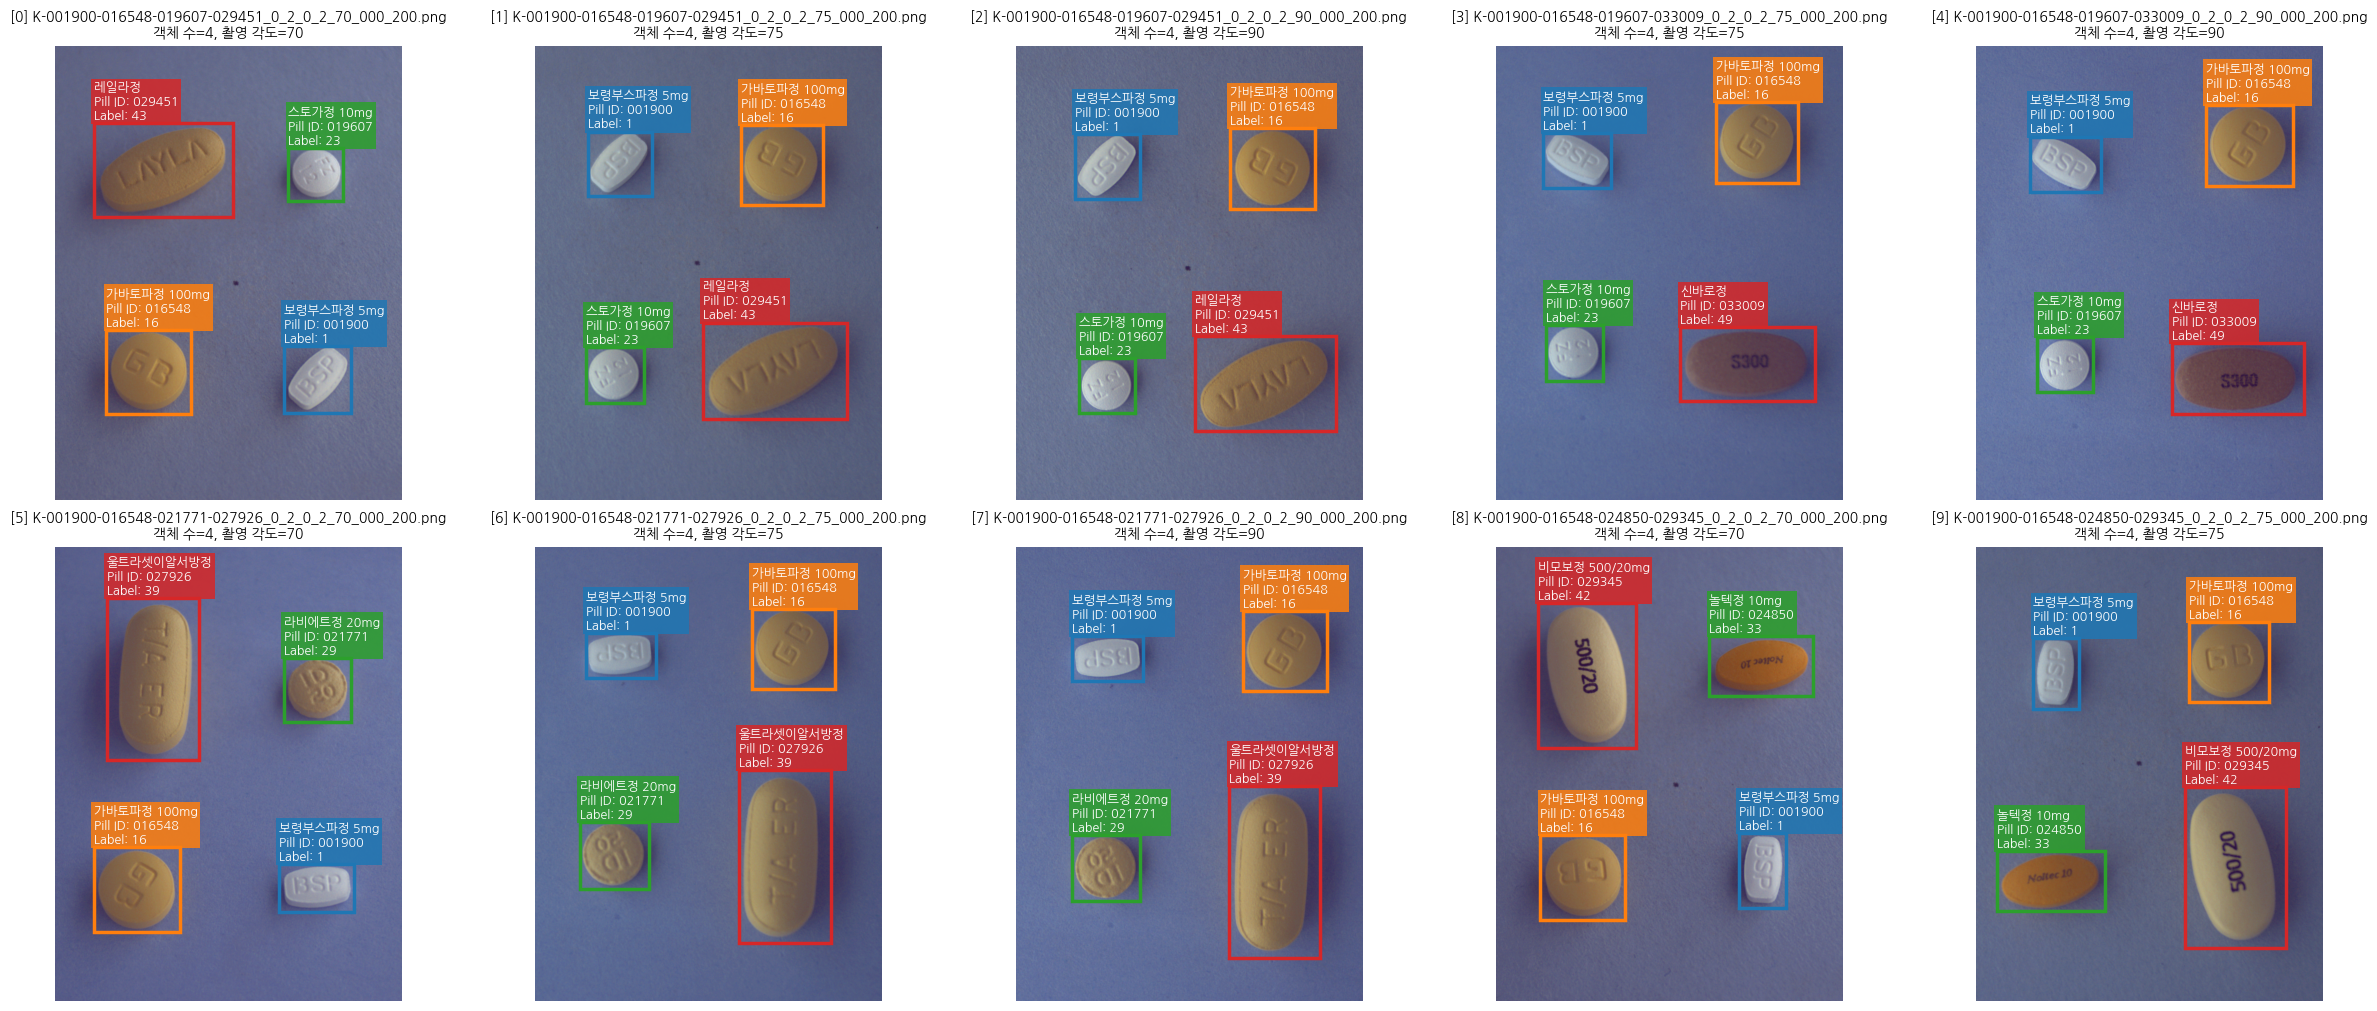

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

import matplotlib.font_manager as fm

from pathlib import Path
from urllib.request import Request, urlopen
import tempfile
import shutil

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


FONT_URL = (
    "https://raw.githubusercontent.com/google/fonts/"
    "main/ofl/nanumgothic/NanumGothic-Regular.ttf"
)

FONT_DIR = Path.home() / ".cache" / "matplotlib-korean-font"
FONT_PATH = FONT_DIR / "NanumGothic-Regular.ttf"


def download_font_if_needed():
    if FONT_PATH.exists() and FONT_PATH.stat().st_size > 0:
        return FONT_PATH

    FONT_DIR.mkdir(parents=True, exist_ok=True)

    request = Request(
        FONT_URL,
        headers={"User-Agent": "Mozilla/5.0"},
    )

    # 다운로드 도중 실패해 불완전한 파일이 남지 않도록 임시 파일 사용
    with urlopen(request, timeout=30) as response:
        with tempfile.NamedTemporaryFile(
            dir=FONT_DIR,
            suffix=".tmp",
            delete=False,
        ) as temp_file:
            shutil.copyfileobj(response, temp_file)
            temp_path = Path(temp_file.name)

    temp_path.replace(FONT_PATH)
    return FONT_PATH


try:
    font_path = download_font_if_needed()

    # 현재 Python 프로세스의 matplotlib에 폰트 등록
    fm.fontManager.addfont(str(font_path))
    font_property = fm.FontProperties(fname=str(font_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()

    plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False

except Exception as e:
    print(f"한글 폰트를 준비하지 못했습니다: {e}")


# Windows 한글 폰트 설정
#font_path = r"C:\Windows\Fonts\malgun.ttf"
#font_property = fm.FontProperties(fname=font_path)
#plt.rcParams["font.family"] = font_property.get_name()
#plt.rcParams["axes.unicode_minus"] = False  # 음수 기호 깨짐 방지


num_images = min(10, len(dataset))
num_cols = 5
num_rows = (num_images + num_cols - 1) // num_cols

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(24, 10),
    constrained_layout=True,
)

axes = np.asarray(axes).reshape(-1)

# 객체를 구분하기 위한 색상
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for index in range(num_images):
    image, target, metadata = dataset[index]
    ax = axes[index]

    ax.imshow(image)

    boxes = target["boxes"].cpu().numpy()
    labels = target["labels"].cpu().numpy()

    for object_index, (box, label) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1

        color = colors[object_index % len(colors)]

        rectangle = Rectangle(
            (x1, y1),
            width,
            height,
            linewidth=2.5,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rectangle)

        try:
            class_name = dataset.get_class_name(int(label))
        except KeyError:
            class_name = "unknown"

        # 현재 bbox에 대응하는 객체 metadata에서 pill ID 추출
        object_metadata = metadata["objects"][object_index]

        pill_id = object_metadata.get("drug_index")
        if str(pill_id).isdigit():
            pill_id = str(pill_id).zfill(6)
            
        # drug_index가 없으면 drug_code에서 ID 추출
        if pill_id is None:
            drug_code = str(object_metadata.get("drug_code", "unknown"))
            pill_id = drug_code.removeprefix("K-")

        text = (
            f"{class_name}\n"
            f"Pill ID: {pill_id}\n"
            f"Label: {int(label)}"
        )

        ax.text(
            x1,
            max(0, y1 - 5),
            text,
            fontsize=9,
            color="white",
            verticalalignment="bottom",
            fontproperties=font_property,
            bbox={
                "facecolor": color,
                "alpha": 0.85,
                "edgecolor": "none",
                "pad": 2,
            },
        )

    ax.set_title(
        f"[{index}] {metadata['file_name']}\n"
        f"객체 수={len(boxes)}, 촬영 각도={metadata['camera_angle_from_filename']}",
        fontsize=10,
        fontproperties=font_property,
    )
    ax.axis("off")

# 이미지 수가 그리드보다 적을 경우 남는 subplot 숨기기
for index in range(num_images, len(axes)):
    axes[index].axis("off")

plt.show()

예시 10개 이미지 시각화

In [9]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.patches import Rectangle


# ============================================================
# 1. 한글 폰트 설정
# ============================================================
from pathlib import Path
from urllib.request import Request, urlopen
import tempfile
import shutil

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


FONT_URL = (
    "https://raw.githubusercontent.com/google/fonts/"
    "main/ofl/nanumgothic/NanumGothic-Regular.ttf"
)

FONT_DIR = Path.home() / ".cache" / "matplotlib-korean-font"
FONT_PATH = FONT_DIR / "NanumGothic-Regular.ttf"


def download_font_if_needed():
    if FONT_PATH.exists() and FONT_PATH.stat().st_size > 0:
        return FONT_PATH

    FONT_DIR.mkdir(parents=True, exist_ok=True)

    request = Request(
        FONT_URL,
        headers={"User-Agent": "Mozilla/5.0"},
    )

    # 다운로드 도중 실패해 불완전한 파일이 남지 않도록 임시 파일 사용
    with urlopen(request, timeout=30) as response:
        with tempfile.NamedTemporaryFile(
            dir=FONT_DIR,
            suffix=".tmp",
            delete=False,
        ) as temp_file:
            shutil.copyfileobj(response, temp_file)
            temp_path = Path(temp_file.name)

    temp_path.replace(FONT_PATH)
    return FONT_PATH


try:
    font_path = download_font_if_needed()

    # 현재 Python 프로세스의 matplotlib에 폰트 등록
    fm.fontManager.addfont(str(font_path))
    font_property = fm.FontProperties(fname=str(font_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()

    plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False

except Exception as e:
    print(f"한글 폰트를 준비하지 못했습니다: {e}")


# ============================================================
# 2. 시각화 설정
# ============================================================
images_per_page = 10
num_cols = 5
num_rows = math.ceil(images_per_page / num_cols)

# True이면 각 페이지를 PNG로 저장
save_figures = True

# True이면 Jupyter 출력창에도 표시
# 전체 데이터셋에서는 출력이 매우 많아질 수 있으므로 False 권장
show_figures = False

output_dir = Path("./bbox_visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

colors = plt.cm.tab10(np.linspace(0, 1, 10))


# ============================================================
# 3. 객체별 pill ID 추출 함수
# ============================================================
def get_pill_id(object_metadata):
    """bbox에 대응하는 객체 metadata에서 6자리 pill ID를 반환합니다."""

    pill_id = object_metadata.get("drug_index")

    if pill_id is None:
        drug_code = str(object_metadata.get("drug_code", "unknown"))
        pill_id = drug_code.removeprefix("K-")

    pill_id = str(pill_id)

    if pill_id.isdigit():
        pill_id = pill_id.zfill(6)

    return pill_id


# ============================================================
# 4. 전체 데이터셋 시각화
# ============================================================
num_images = len(dataset)
num_pages = math.ceil(num_images / images_per_page)

print(f"전체 이미지 수: {num_images}")
print(f"생성할 페이지 수: {num_pages}")

for page_index in range(num_pages):
    start_index = page_index * images_per_page
    end_index = min(start_index + images_per_page, num_images)
    current_page_size = end_index - start_index

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(25, 11),
        constrained_layout=True,
    )

    axes = np.asarray(axes).reshape(-1)

    for subplot_index, dataset_index in enumerate(
        range(start_index, end_index)
    ):
        image, target, metadata = dataset[dataset_index]
        ax = axes[subplot_index]

        ax.imshow(image)

        boxes = target["boxes"].detach().cpu().numpy()
        labels = target["labels"].detach().cpu().numpy()
        objects_metadata = metadata.get("objects", [])

        for object_index, (box, label) in enumerate(zip(boxes, labels)):
            x1, y1, x2, y2 = map(float, box)

            width = x2 - x1
            height = y2 - y1

            color = colors[object_index % len(colors)]

            # Bounding box
            rectangle = Rectangle(
                (x1, y1),
                width,
                height,
                linewidth=2.5,
                edgecolor=color,
                facecolor="none",
            )
            ax.add_patch(rectangle)

            # 클래스 이름
            try:
                class_name = dataset.get_class_name(int(label))
            except KeyError:
                class_name = "unknown"

            # bbox와 대응하는 객체 metadata
            if object_index < len(objects_metadata):
                object_metadata = objects_metadata[object_index]
                pill_id = get_pill_id(object_metadata)
            else:
                pill_id = "unknown"

            annotation_text = (
                f"{class_name}\n"
                f"Pill ID: {pill_id}\n"
                f"Label: {int(label)}"
            )

            # 이미지 위쪽을 벗어나지 않도록 텍스트 위치 결정
            if y1 >= 70:
                text_y = y1 - 5
                vertical_alignment = "bottom"
            else:
                text_y = y1 + 5
                vertical_alignment = "top"

            ax.text(
                x1,
                text_y,
                annotation_text,
                fontsize=8,
                color="white",
                verticalalignment=vertical_alignment,
                fontproperties=font_property,
                bbox={
                    "facecolor": color,
                    "alpha": 0.85,
                    "edgecolor": "none",
                    "pad": 2,
                },
            )

        camera_angle = metadata.get(
            "camera_angle_from_filename",
            "unknown",
        )

        ax.set_title(
            f"[{dataset_index}] {metadata['file_name']}\n"
            f"객체 수: {len(boxes)} | 촬영 각도: {camera_angle}",
            fontsize=9,
            fontproperties=font_property,
        )
        ax.axis("off")

    # 마지막 페이지의 비어 있는 subplot 숨기기
    for subplot_index in range(current_page_size, len(axes)):
        axes[subplot_index].axis("off")

    fig.suptitle(
        f"Pill Detection Dataset "
        f"({start_index + 1}–{end_index} / {num_images})",
        fontsize=18,
        fontproperties=font_property,
    )

    if save_figures:
        output_path = output_dir / f"bbox_page_{page_index + 1:03d}.png"

        fig.savefig(
            output_path,
            dpi=150,
            bbox_inches="tight",
            facecolor="white",
        )

        print(
            f"[{page_index + 1:03d}/{num_pages:03d}] "
            f"저장 완료: {output_path}"
        )

    if show_figures:
        plt.show()

    # 다음 페이지를 생성하기 전에 figure 메모리 해제
    plt.close(fig)

print(f"\n전체 시각화 완료: {output_dir.resolve()}")

전체 이미지 수: 219
생성할 페이지 수: 22
[001/022] 저장 완료: bbox_visualizations\bbox_page_001.png
[002/022] 저장 완료: bbox_visualizations\bbox_page_002.png
[003/022] 저장 완료: bbox_visualizations\bbox_page_003.png
[004/022] 저장 완료: bbox_visualizations\bbox_page_004.png
[005/022] 저장 완료: bbox_visualizations\bbox_page_005.png


C:\Users\soulf\AppData\Local\Temp\ipykernel_32620\2792778090.py:235: UserWarning: Glyph 160 (\N{NO-BREAK SPACE}) missing from font(s) NanumGothic.
  fig.savefig(


[006/022] 저장 완료: bbox_visualizations\bbox_page_006.png
[007/022] 저장 완료: bbox_visualizations\bbox_page_007.png
[008/022] 저장 완료: bbox_visualizations\bbox_page_008.png
[009/022] 저장 완료: bbox_visualizations\bbox_page_009.png
[010/022] 저장 완료: bbox_visualizations\bbox_page_010.png
[011/022] 저장 완료: bbox_visualizations\bbox_page_011.png
[012/022] 저장 완료: bbox_visualizations\bbox_page_012.png
[013/022] 저장 완료: bbox_visualizations\bbox_page_013.png
[014/022] 저장 완료: bbox_visualizations\bbox_page_014.png
[015/022] 저장 완료: bbox_visualizations\bbox_page_015.png
[016/022] 저장 완료: bbox_visualizations\bbox_page_016.png
[017/022] 저장 완료: bbox_visualizations\bbox_page_017.png
[018/022] 저장 완료: bbox_visualizations\bbox_page_018.png
[019/022] 저장 완료: bbox_visualizations\bbox_page_019.png
[020/022] 저장 완료: bbox_visualizations\bbox_page_020.png
[021/022] 저장 완료: bbox_visualizations\bbox_page_021.png
[022/022] 저장 완료: bbox_visualizations\bbox_page_022.png

전체 시각화 완료: C:\Users\soulf\Downloads\ai13-level1-project\bbox_vis

bbox 전체 시각화 코드. 이미지 10개마다 파일로 내보냄.